# Estudio Laboratory Data

## Overview

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\Usuario\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\Users\Usuario\anaconda3\Lib\site-packages\traitlets\config\application.py", line 992, in launch_instance
    app.start()
  File "C:\Users\Usuario\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 736, in start
    self.io_loop.start()
  File "C:\Users\Usuario\anaconda3\Lib\si

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\Usuario\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\Users\Usuario\anaconda3\Lib\site-packages\traitlets\config\application.py", line 992, in launch_instance
    app.start()
  File "C:\Users\Usuario\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 736, in start
    self.io_loop.start()
  File "C:\Users\Usuario\anaconda3\Lib\si

AttributeError: _ARRAY_API not found

In [2]:
# Cargar el dataset
path = 'data/merged_sets/merged_lab_data_clean.csv'
df_exam = pd.read_csv(path)

# Descartar el identificador SEQN
if 'SEQN' in df_exam.columns:
    df_exam = df_exam.drop(columns=['SEQN'])
    print("Columna 'SEQN' eliminada correctamente.")

# 1. Qué tipo de variables tenemos
print("--- Estructura del Dataset ---")
print(df_exam.info())

print("\n--- Conteo de tipos de datos ---")
print(df_exam.dtypes.value_counts())

# Separación sugerida para análisis
numeric_cols = df_exam.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df_exam.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"\nVariables Numéricas ({len(numeric_cols)}): {numeric_cols[:5]}...") # Mostramos solo las primeras 5
print(f"Variables Categóricas ({len(categorical_cols)}): {categorical_cols}")

Columna 'SEQN' eliminada correctamente.
--- Estructura del Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 3996 entries, 0 to 3995
Data columns (total 57 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   URXUMA    3889 non-null   float64
 1   URXUMS    3889 non-null   float64
 2   URDUMALC  3889 non-null   float64
 3   URXUCR    3889 non-null   float64
 4   URXCRS    3889 non-null   float64
 5   URDUCRLC  3889 non-null   float64
 6   URDACT    3889 non-null   float64
 7   WTPH2YR   3996 non-null   float64
 8   LBXWBCSI  3738 non-null   float64
 9   LBXLYPCT  3732 non-null   float64
 10  LBXMOPCT  3732 non-null   float64
 11  LBXNEPCT  3732 non-null   float64
 12  LBXEOPCT  3732 non-null   float64
 13  LBXBAPCT  3732 non-null   float64
 14  LBDLYMNO  3732 non-null   float64
 15  LBDMONO   3732 non-null   float64
 16  LBDNENO   3732 non-null   float64
 17  LBDEONO   3732 non-null   float64
 18  LBDBANO   3732 non-null   float64
 19  LBXRBCSI 

--- Columnas con valores faltantes ---
          Nulos  Porcentaje (%)
LBDLDL      516       12.912913
LBDLDLSI    516       12.912913
LBDLDLM     516       12.912913
LBDLDMSI    516       12.912913
LBDLDLN     483       12.087087
LBDLDNSI    483       12.087087
LBDTRSI     479       11.986987
LBXTLG      479       11.986987
LBDHDDSI    450       11.261261
LBDHDD      450       11.261261
LBXHSCRP    376        9.409409
LBDHRPLC    376        9.409409
LBXNRBC     264        6.606607
LBDBANO     264        6.606607
LBDMONO     264        6.606607
LBDLYMNO    264        6.606607
LBDEONO     264        6.606607
LBDNENO     264        6.606607
LBXNEPCT    264        6.606607
LBXMOPCT    264        6.606607
LBXBAPCT    264        6.606607
LBXEOPCT    264        6.606607
LBXLYPCT    264        6.606607
LBXRBCSI    258        6.456456
LBXWBCSI    258        6.456456
LBXMCHSI    258        6.456456
LBXMC       258        6.456456
LBXMCVSI    258        6.456456
LBXHCT      258        6.456456
L

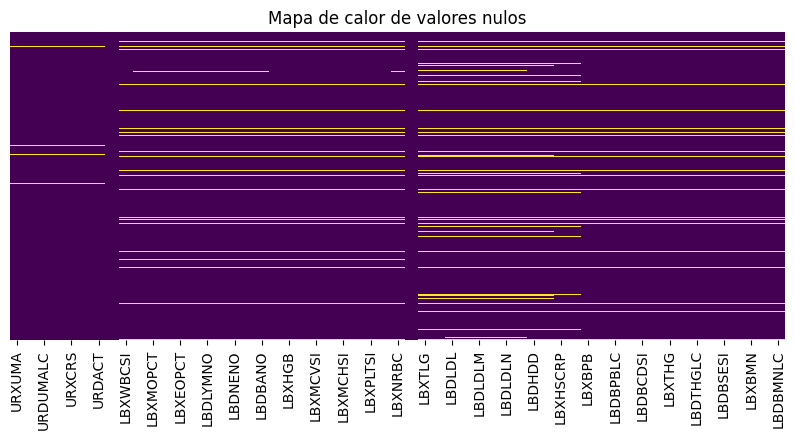

In [3]:
# 2. Análisis de nulos
null_count = df_exam.isnull().sum()
null_percentage = (null_count / len(df_exam)) * 100

null_df = pd.DataFrame({
    'Nulos': null_count,
    'Porcentaje (%)': null_percentage
}).sort_values(by='Nulos', ascending=False)

# Mostrar solo las columnas que tienen nulos
print("--- Columnas con valores faltantes ---")
print(null_df[null_df['Nulos'] > 0])

# Visualización rápida de nulos
plt.figure(figsize=(10, 4))
sns.heatmap(df_exam.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Mapa de calor de valores nulos')
plt.show()

--- Resumen de Outliers en el Dataset ---


,Columna,Outliers,Porcentaje (%)
50,LBDTHGLC,762,19.07
6,URDACT,518,12.96
0,URXUMA,492,12.31
1,URXUMS,492,12.31
17,LBDEONO,358,8.96
46,LBDBCDSI,345,8.63
45,LBXBCD,345,8.63
48,LBXTHG,330,8.26
49,LBDTHGSI,330,8.26
40,LBXHSCRP,315,7.88


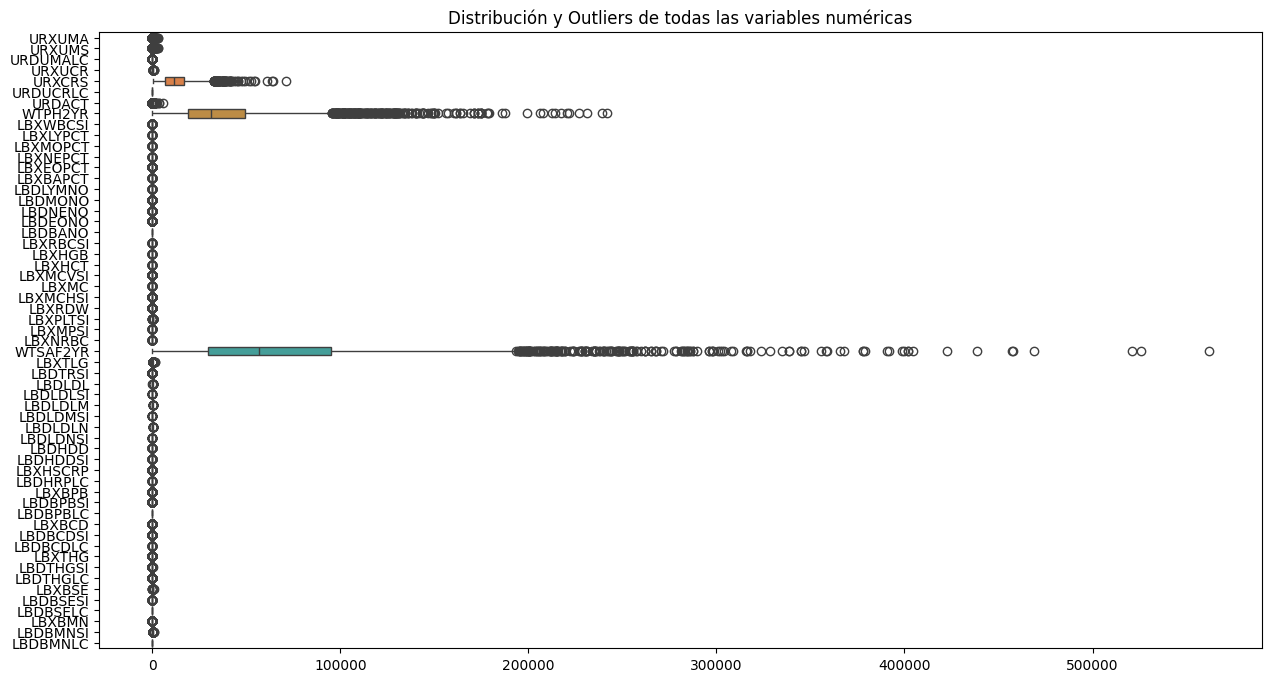

In [4]:
# 2. Análisis de Outliers
outliers_summary = []

for col in numeric_cols:
    Q1 = df_exam[col].quantile(0.25)
    Q3 = df_exam[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Contar cuántos valores están fuera de los límites
    num_outliers = df_exam[(df_exam[col] < lower_bound) | (df_exam[col] > upper_bound)].shape[0]
    perc_outliers = (num_outliers / len(df_exam)) * 100
    
    outliers_summary.append({
        'Columna': col,
        'Outliers': num_outliers,
        'Porcentaje (%)': round(perc_outliers, 2)
    })

# Convertir a DataFrame para visualizar mejor
df_outliers = pd.DataFrame(outliers_summary).sort_values(by='Outliers', ascending=False)
print("--- Resumen de Outliers en el Dataset ---")
display(df_outliers)

# Visualización general (Boxplot de todas las variables normalizadas para comparar)
plt.figure(figsize=(15, 8))
sns.boxplot(data=df_exam[numeric_cols], orient="h")
plt.title("Distribución y Outliers de todas las variables numéricas")
plt.show()

--- Estadísticos Principales ---


,URXUMA,URXUMS,URDUMALC,URXUCR,URXCRS,URDUCRLC,URDACT,WTPH2YR,LBXWBCSI,LBXLYPCT,...,LBDBCDLC,LBXTHG,LBDTHGSI,LBDTHGLC,LBXBSE,LBDBSESI,LBDBSELC,LBXBMN,LBDBMNSI,LBDBMNLC
count,3889.000000,3889.000000,3.889000e+03,3889.000000,3889.000000,3.889000e+03,3889.000000,3.996000e+03,3738.000000,3732.000000,...,3.741000e+03,3741.000000,3741.000000,3.741000e+03,3741.000000,3741.000000,3.741000e+03,3741.000000,3741.000000,3.741000e+03
mean,37.877136,37.877136,5.451273e-02,143.884803,12719.416611,5.397605e-79,31.456614,3.888981e+04,6.548074,30.394105,...,1.550388e-02,1.168543,5.831729,2.036889e-01,180.658166,2.294314,5.397605e-79,9.698455,176.531358,5.397605e-79
std,158.695799,158.695799,2.270558e-01,91.903634,8124.281215,0.000000e+00,168.777459,3.086787e+04,1.949863,8.727410,...,1.235621e-01,2.069504,10.326533,4.027941e-01,28.657243,0.363968,0.000000e+00,3.658851,66.598406,0.000000e+00
min,0.210000,0.210000,5.397605e-79,5.000000,442.000000,5.397605e-79,0.220000,5.397605e-79,2.200000,4.700000,...,5.397605e-79,0.120000,0.600000,5.397605e-79,86.000000,1.090000,5.397605e-79,2.980000,54.240000,5.397605e-79
25%,6.150000,6.150000,5.397605e-79,75.000000,6630.000000,5.397605e-79,5.070000,1.881012e+04,5.200000,24.300000,...,5.397605e-79,0.210000,1.050000,5.397605e-79,163.900000,2.080000,5.397605e-79,7.310000,133.060000,5.397605e-79
50%,10.020000,10.020000,5.397605e-79,129.000000,11403.600000,5.397605e-79,7.720000,3.126342e+04,6.300000,29.900000,...,5.397605e-79,0.530000,2.640000,5.397605e-79,177.200000,2.250000,5.397605e-79,9.010000,164.000000,5.397605e-79
75%,18.600000,18.600000,5.397605e-79,193.000000,17061.200000,5.397605e-79,14.270000,4.943884e+04,7.500000,35.800000,...,5.397605e-79,1.290000,6.440000,5.397605e-79,192.800000,2.450000,5.397605e-79,11.300000,205.680000,5.397605e-79
max,3325.460000,3325.460000,1.000000e+00,805.000000,71162.000000,5.397605e-79,5763.610000,2.417289e+05,18.400000,67.600000,...,1.000000e+00,42.490000,212.030000,1.000000e+00,752.400000,9.560000,5.397605e-79,52.710000,959.430000,5.397605e-79


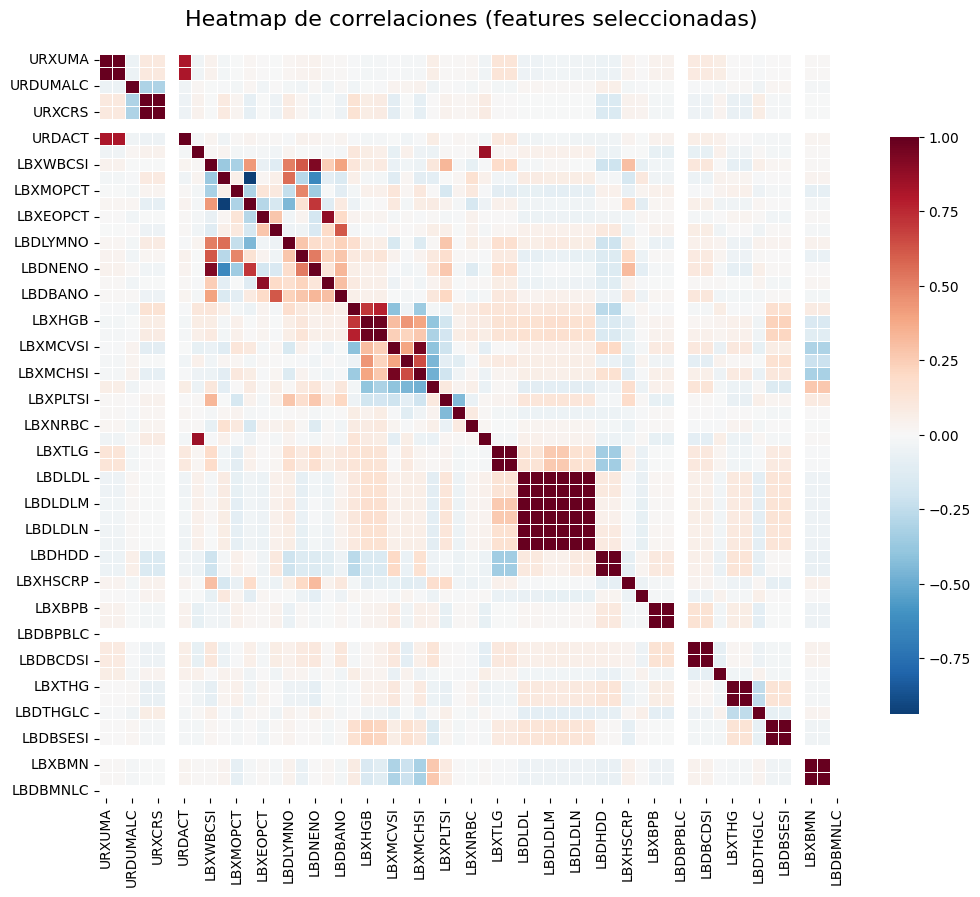


--- Parejas de variables con mayor correlación positiva ---


URXUMA  URXUMS      1.0
URXUCR  URXCRS      1.0
LBXBMN  LBDBMNSI    1.0
LBXBCD  LBDBCDSI    1.0
LBXTHG  LBDTHGSI    1.0
dtype: float64


--- Parejas de variables con mayor correlación negativa ---


LBDBMNLC  LBDBSESI   NaN
          LBDBSELC   NaN
          LBXBMN     NaN
          LBDBMNSI   NaN
          LBDBMNLC   NaN
dtype: float64

In [8]:
# 3. Análisis Estadístico Descriptivo
print("--- Estadísticos Principales ---")
display(df_exam.describe())

# 4. Visualización de correlación 
# Calculamos la matriz
corr_matrix = df_exam[numeric_cols].corr()

# Configuramos el tamaño de la figura
plt.figure(figsize=(12, 10))

# Dibujamos el heatmap 
sns.heatmap(corr_matrix, 
            annot=False, 
            cmap='RdBu_r', 
            center=0,
            linewidths=.5, 
            linecolor='white',
            square=True,
            cbar_kws={"shrink": .75})

# Ajustes de etiquetas y título
plt.title("Heatmap de correlaciones (features seleccionadas)", fontsize=16, pad=20)
plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.show()

# Ranking de correlaciones (para no perder el dato exacto del Top 5)
sol = (corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
                  .stack()
                  .sort_values(ascending=False))

print("\n--- Parejas de variables con mayor correlación positiva ---")
display(sol.head(5))

print("\n--- Parejas de variables con mayor correlación negativa ---")
display(sol.tail(5))